# 第070讲 流形与可视化的边界

固定连续卷曲表面，检查局部和全局结构，不按美观选择图。所有输出由真实内核执行。数据颜色只用于审计，不参与拟合。

In [1]:
import warnings
# 本实验不使用交互式进度条；仅关闭可选IProgress组件提示。
warnings.filterwarnings("ignore", message="IProgress not found.*")
import os
os.environ["NUMBA_NUM_THREADS"]="1"
os.environ["OMP_NUM_THREADS"]="1"
import numpy as np
from pathlib import Path
from IPython.display import display, Image
from common import load_data
from neighborhoods import trust, recall
from experiment import run
data=load_data()
print({name: len(part["id"]) for name,part in data.items()})

{'roll': 320, 'gaussian': 240}


## 四点手算
排除自身，先列出最近邻，再按原空间排名惩罚。

In [2]:
H=np.array([[0.],[1.],[3.],[7.]])
Z=np.array([[0.],[3.],[1.],[7.]])
print("T1",trust(H,Z,1),"R1",recall(H,Z,1))

T1 0.5 R1 0.0


## 一次完整参数与种子扫描
运行14组卷曲表面映射和2组Gaussian对照。首次UMAP可能包含即时编译，耗时不作为公平速度比较。

In [3]:
report=run()
print("roll configurations",len(report["records"]))
for row in report["records"]:
    m=row["metrics"]
    print(row["method"],row["seed"],row["parameter"],row.get("min_dist"),"T10",round(m["trustworthiness_10"],4),"R10",round(m["neighbor_recall_10"],4),"intrinsic global",round(m["intrinsic_global_distance_spearman"],4))

roll configurations 14
PCA None 2 None T10 0.8983 R10 0.585 intrinsic global 0.3453
t-SNE 0 5 None T10 0.9931 R10 0.7519 intrinsic global 0.6741
t-SNE 0 30 None T10 0.9962 R10 0.8325 intrinsic global 0.2931
t-SNE 0 80 None T10 0.9869 R10 0.715 intrinsic global 0.1691
t-SNE 1 5 None T10 0.9932 R10 0.7503 intrinsic global 0.6673
t-SNE 1 30 None T10 0.9949 R10 0.8297 intrinsic global 0.2867
t-SNE 1 80 None T10 0.9902 R10 0.765 intrinsic global 0.3055
UMAP 0 5 0.1 T10 0.9897 R10 0.7109 intrinsic global 0.6257
UMAP 0 30 0.1 T10 0.9792 R10 0.5825 intrinsic global 0.2275
UMAP 0 80 0.1 T10 0.9345 R10 0.3859 intrinsic global 0.2388
UMAP 1 5 0.1 T10 0.9906 R10 0.7122 intrinsic global 0.7196
UMAP 1 30 0.1 T10 0.9776 R10 0.5772 intrinsic global 0.2292
UMAP 1 80 0.1 T10 0.9378 R10 0.3981 intrinsic global 0.2314
UMAP 0 30 0.8 T10 0.9491 R10 0.5316 intrinsic global 0.2805


## 两种距离不混用
输入邻域使用观测三维直线距离；内在诊断使用解析弧长与高度。

In [4]:
chosen=next(z for z in report["records"] if z["method"]=="t-SNE" and z["seed"]==0 and z["parameter"]==30)
print(chosen["metrics"])
print("maximum library trust error",max(z["metrics"]["library_trust_error"] for z in report["records"]))

{'trustworthiness_10': 0.9961945812807882, 'neighbor_recall_10': 0.8325000000000001, 'global_distance_spearman': 0.6124038658550197, 'library_trust_error': np.float64(0.0), 'intrinsic_neighbor_recall_10': 0.8309374999999999, 'intrinsic_global_distance_spearman': 0.29307620751767954}
maximum library trust error 0.0


## 负对照
这些点来自单一标准Gaussian，没有预设混合类别。局部空隙不是类别证据。

In [5]:
for row in report["null_control"]:
    print(row["seed"],row["metrics"])

0 {'trustworthiness_10': 0.9138938381588716, 'neighbor_recall_10': 0.4995833333333333, 'global_distance_spearman': 0.4753621996247051, 'library_trust_error': np.float64(0.0)}
1 {'trustworthiness_10': 0.9074981440237565, 'neighbor_recall_10': 0.48500000000000004, 'global_distance_spearman': 0.47369523856007784, 'library_trust_error': np.float64(0.0)}


In [6]:
from plots import draw
names=draw(report,Path("outputs/notebook-figures"))
print("generated",len(names),"figures")

generated 7 figures


### 已知连续结构

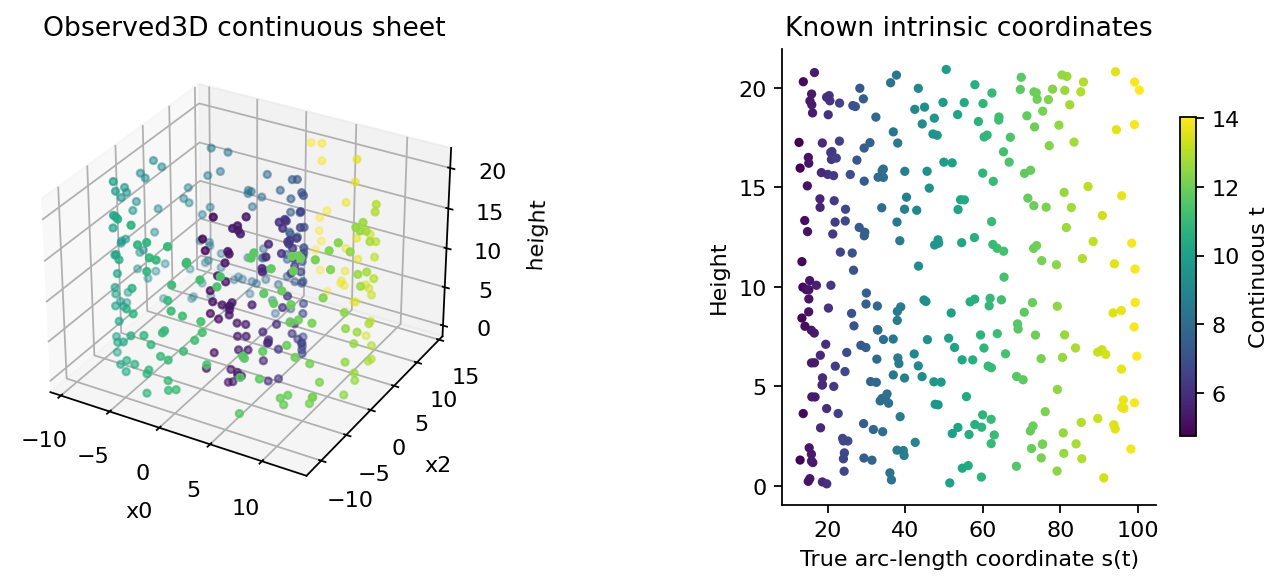

In [7]:
display(Image(filename="outputs/notebook-figures/01_known_geometry.png"))

### 线性基线

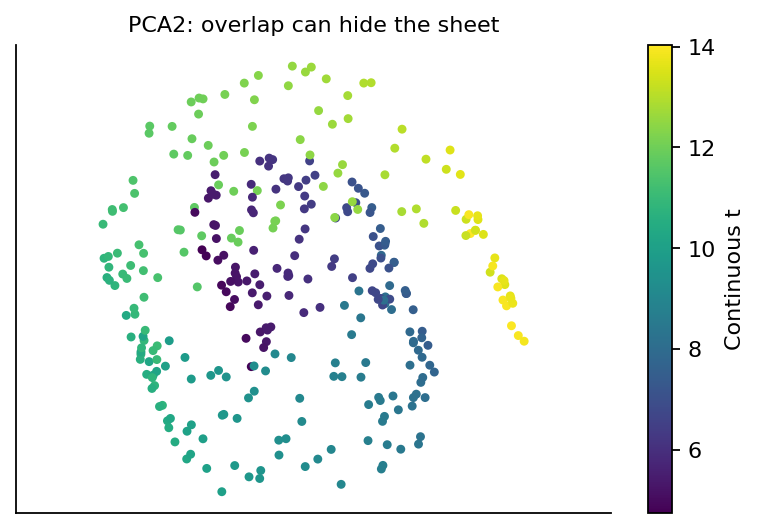

In [8]:
display(Image(filename="outputs/notebook-figures/02_pca_projection.png"))

### t-SNE全部参数与种子

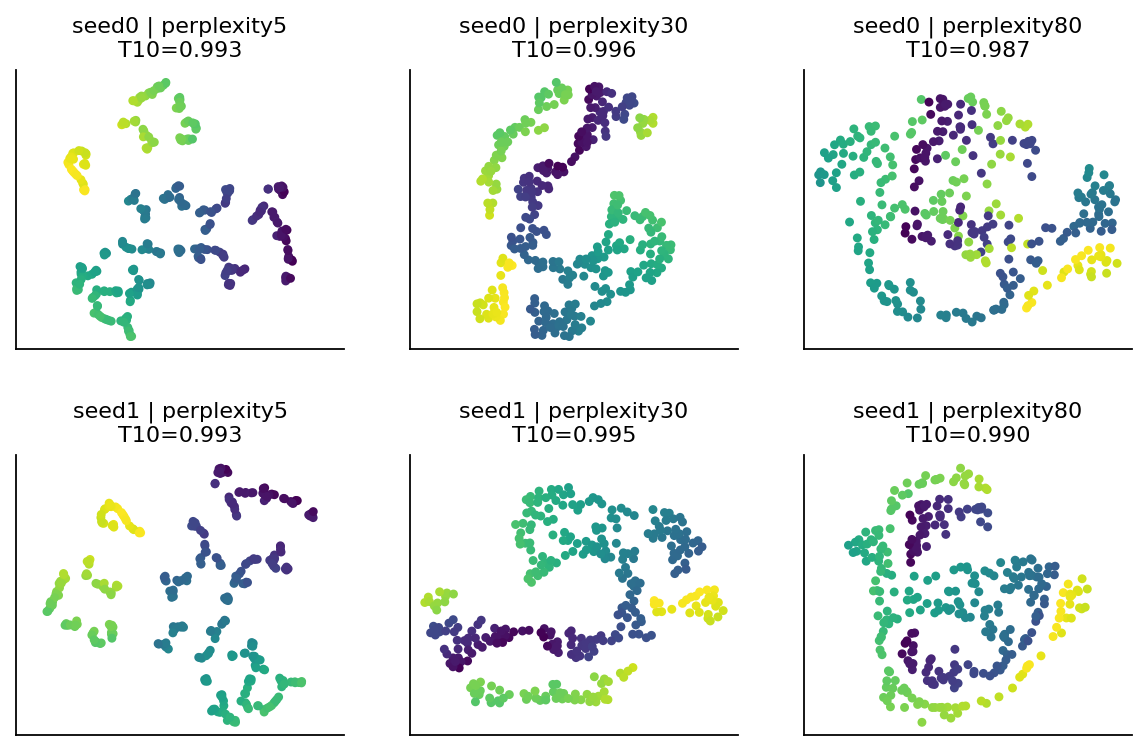

In [9]:
display(Image(filename="outputs/notebook-figures/03_tsne_sweep.png"))

### UMAP全部参数与种子

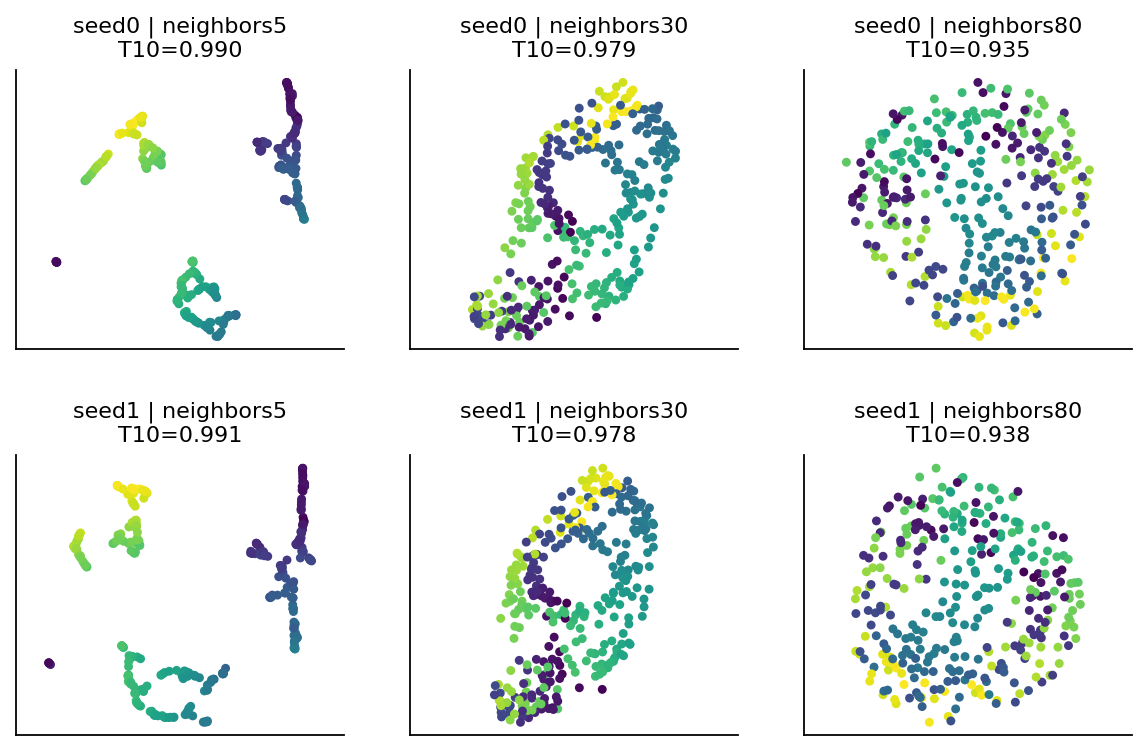

In [10]:
display(Image(filename="outputs/notebook-figures/04_umap_sweep.png"))

### 只改变低维紧凑程度

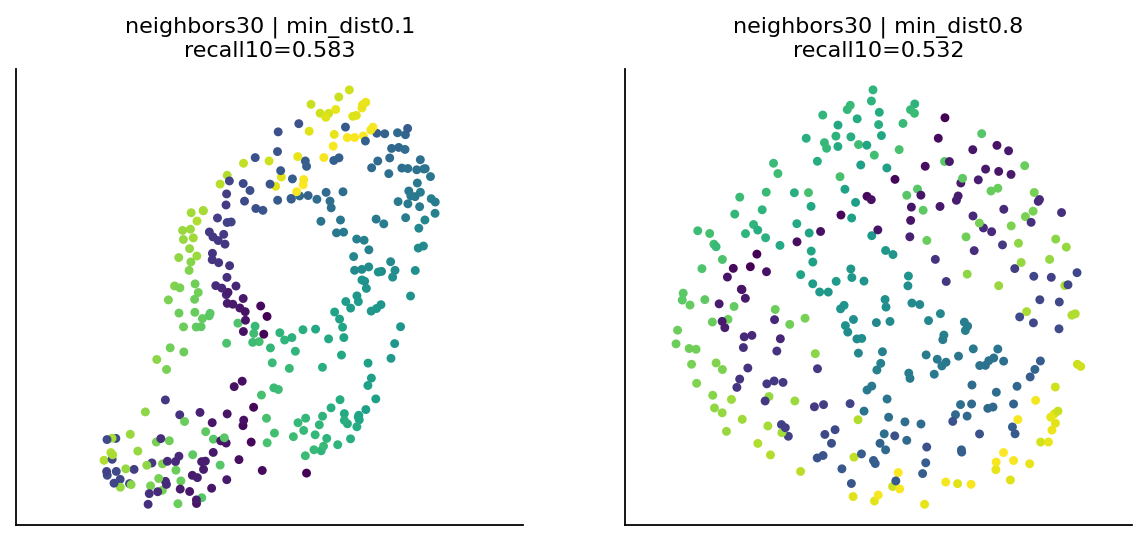

In [11]:
display(Image(filename="outputs/notebook-figures/05_min_dist.png"))

### 局部与全局诊断

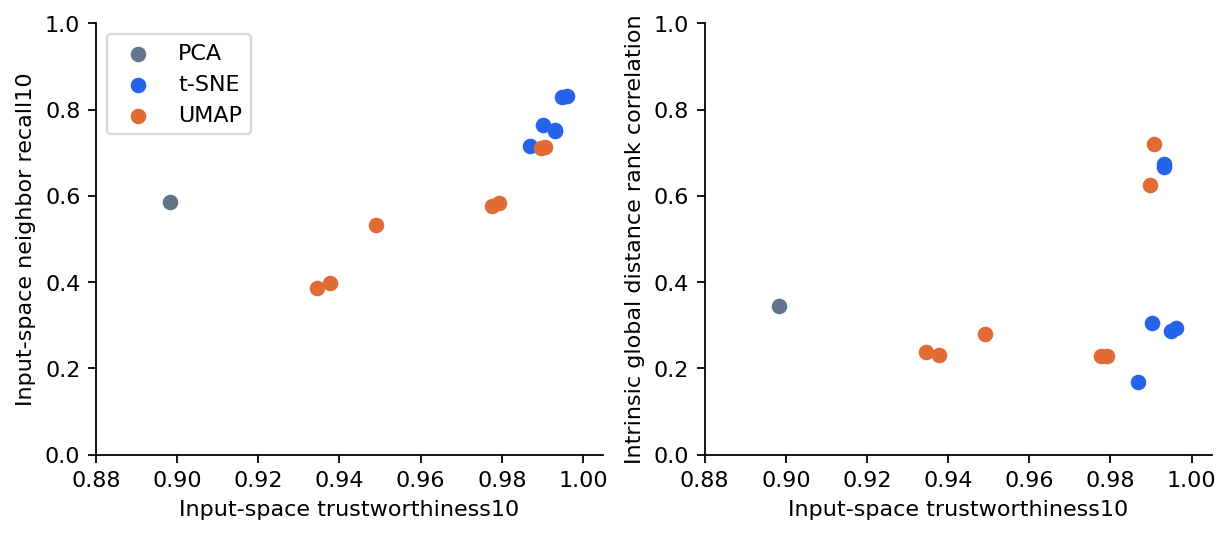

In [12]:
display(Image(filename="outputs/notebook-figures/06_local_global_metrics.png"))

### 单Gaussian负对照

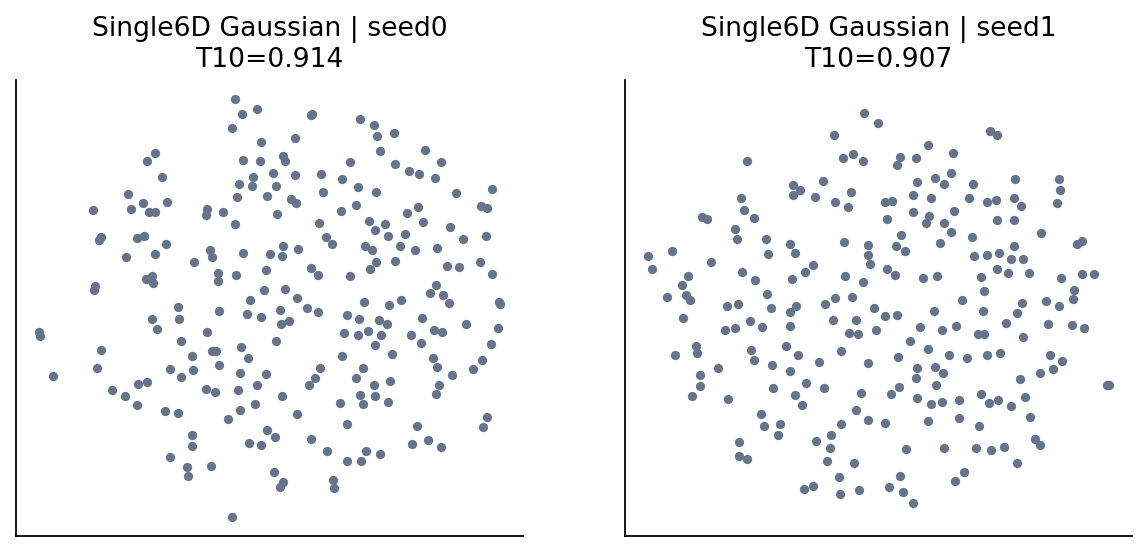

In [13]:
display(Image(filename="outputs/notebook-figures/07_gaussian_null.png"))

## 结论边界
全部点参与映射，所以指标是探索性几何诊断，不是新样本预测准确率。高T不等于相同比例的近邻重合，也不保证全局距离。科学分群结论还需原空间与独立证据。